
step size = 0.01
errors at each point = [0. 0. 0. ... 0. 0. 0.]
total error = 0.0

step size = 0.060000000000000005
errors at each point = [0.         0.00579066 0.01035256 0.01385566 0.0164624  0.01832346
 0.01957525 0.02033857 0.02071846 0.02080464 0.02067264 0.02038508
 0.01999326 0.01953862 0.01905434 0.01856669 0.01809634 0.0176595
 0.01726892 0.01693475 0.01666531 0.01646771 0.01634841 0.01631373
 0.01637027 0.0165253  0.01678719 0.0171658  0.01767283 0.01832234
 0.01913116 0.02011949 0.02131147 0.02273594 0.02442724 0.02642616
 0.028781   0.03154884 0.0347969  0.03860414 0.04306294 0.048281
 0.05438332 0.06151427 0.06983967 0.07954876 0.09085595 0.10400213
 0.11925539 0.13691083 0.15728914 0.18073367 0.20760549 0.23827626
 0.27311835 0.31249208 0.3567299  0.40611744 0.46087183 0.52111769
 0.58686172 0.65796718 0.7341297  0.81485646 0.89945078 0.98700417
 1.07639812 1.16631705 1.25527369 1.34164713 1.42373285 1.49980291
 1.56817348 1.62727588 1.67572666 1.71239175 1.73644028 1.7

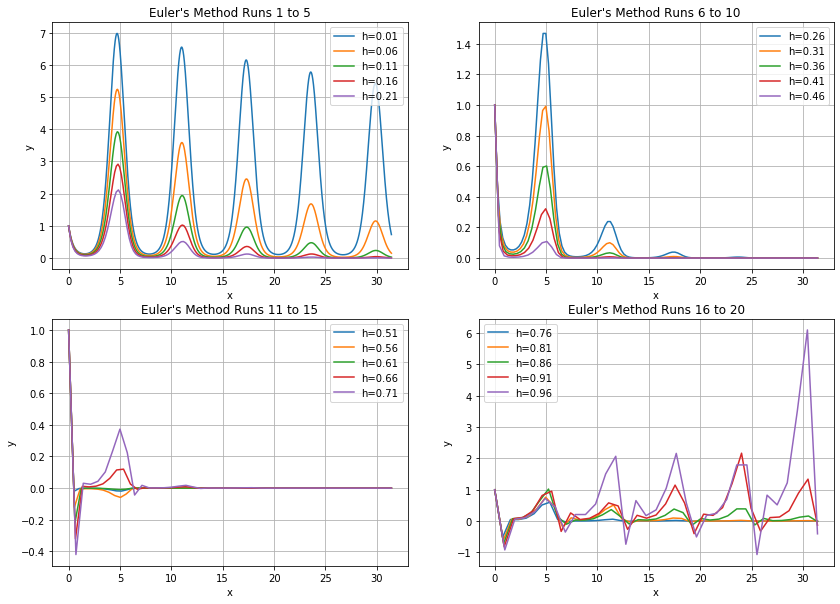

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# Define parameters
h_vals = np.arange(0.01, 1.00, 0.05) # step size
#print(len(h_vals)) #debug
x_start, x_end = 0, 10*np.pi

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y * np.cos(x)

#subplots to keep organized
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Implement Euler's method

for j in range(len(h_vals)): 
    #set up
    h = h_vals[j]
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    
    # Initial condition
    y_values[0] = 1  # y(0) = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    #save first run and compare to curr run
    if j == 0:
        first_x = x_values.copy()
        first_y = y_values.copy()
        
    #compare current run to first run - need to match up the x values to be able to compare
    first_y_interp = np.interp(x_values, first_x, first_y) 
    errors = np.abs(y_values - first_y_interp)
    total_error = np.sum(errors)
    
    print()
    print("step size =", h)
    print("errors at each point =", errors)
    print("total error =", total_error)
    
    #choose what subplot it goes on
    plot_num = j // 5 #5 lines per subplot
    axes[plot_num].plot(x_values, y_values, label=f"h={h:.2f}")
#labeling each subplot gragh
for k in range(4):
    axes[k].set_xlabel('x')
    axes[k].set_ylabel('y')
    axes[k].set_title(f"Euler's Method Runs {k*5 + 1} to {min((k+1)*5, len(h_vals))}")
    axes[k].legend()
    axes[k].grid(True)
    

plt.show()
